In [1]:
import sys
sys.path.append('../')

import os
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

from utils.files import project_root
from utils.plotting import *
from utils.helpers import *

In [2]:
save_figs = True
selser_base_dir = os.path.join(project_root(), 'outputs', 'selser')
medusa_base_dir = os.path.join(project_root(), 'outputs', 'medusa_graphtrip')

# Plotting function

In [3]:
def true_vs_pred_scatter_with_regressline(ypreds, marker_col=None, style=None, title=None, 
                         save_path=None, xcol='label', ycol='prediction'):
    """
    Create a scatter plot of true vs predicted values.
    
    Parameters:
    ypreds (pd.DataFrame): DataFrame containing columns for x and y values, and optionally 'Condition' column
    marker_col (str): Optional column name in ypreds to determine marker symbols
    style (str): Optional style for markers if 'Condition' column is not present. Can be 'psilo' or 'escit'
    title (str): Optional title for the plot
    save_path (str): Optional path to save the figure
    xcol (str): Name of column to use for x-axis values (default: 'label')
    ycol (str): Name of column to use for y-axis values (default: 'prediction')
    """
    plt.figure(figsize=(6, 5))

    # Define marker mapping if marker_col is provided
    if marker_col is not None:
        unique_markers = ypreds[marker_col].unique()
        marker_map = {val: marker for val, marker in 
                     zip(unique_markers, ['o', 'x', 'd', '^', 'v', '>', '<', 'p', 'h', '8'])}

    # Flag: do condition-specific scatter, regression, lines, and r annotation if Condition in columns
    if 'Condition' in ypreds.columns:
        condition_psilo = ypreds[ypreds['Condition'] == 1.0]
        condition_escit = ypreds[ypreds['Condition'] == -1.0]

        # Plot scatter for PSILO and ESCIT
        if marker_col is not None:
            for marker_val in ypreds[marker_col].unique():
                # Plot psilo points with this marker
                mask_psilo = condition_psilo[marker_col] == marker_val
                if mask_psilo.any():
                    plt.scatter(condition_psilo[mask_psilo][xcol],
                                condition_psilo[mask_psilo][ycol],
                                marker=marker_map[marker_val], 
                                color=PSILO, edgecolor=PSILO, 
                                alpha=ALPHA_SCATTER)
                # Plot escit points with this marker
                mask_escit = condition_escit[marker_col] == marker_val
                if mask_escit.any():
                    plt.scatter(condition_escit[mask_escit][xcol],
                                condition_escit[mask_escit][ycol],
                                marker=marker_map[marker_val], 
                                color=ESCIT, edgecolor=ESCIT, 
                                alpha=ALPHA_SCATTER)
        else:
            plt.scatter(condition_psilo[xcol], condition_psilo[ycol],
                        marker='d', color=PSILO, edgecolor=PSILO, alpha=ALPHA_SCATTER)
            plt.scatter(condition_escit[xcol], condition_escit[ycol],
                        marker='o', color=ESCIT, edgecolor=ESCIT, alpha=ALPHA_SCATTER)

        # Regression lines + r annotation for each condition
        for cond, cond_name, cond_color, cond_marker, y_off in [
            (condition_psilo, "Psilocybin", PSILO, 'd', 0.06),
            (condition_escit, "Escitalopram", ESCIT, 'o', 0.0)
        ]:
            if not cond.empty:
                x = cond[xcol].values
                y = cond[ycol].values
                # Fit regression
                if len(x) > 1 and np.std(x) > 1e-9 and np.std(y) > 1e-9:
                    coeffs = np.polyfit(x, y, 1)
                    fit_x = np.linspace(min(x), max(x), 100)
                    fit_y = np.polyval(coeffs, fit_x)
                    plt.plot(fit_x, fit_y, '-', color=cond_color, alpha=0.93, linewidth=2)
                else:
                    coeffs = [np.nan, np.nan]
                # Pearson r
                if len(x) > 1:
                    r, _ = pearsonr(x, y)
                else:
                    r = np.nan
                # Find annotation spot near top edge of plot just above the regression line
                x_annot = np.percentile(x, 85) if len(x) > 1 else (x[0] if len(x) else 0)
                if np.isnan(coeffs[0]):
                    y_annot = (max(y) if len(y) else 0) + y_off * (plt.ylim()[1] - plt.ylim()[0])
                else:
                    y_annot = np.polyval(coeffs, x_annot) + y_off * (plt.ylim()[1] - plt.ylim()[0])
                label_text = f"r={r:.3f}"
                plt.text(x_annot, y_annot, label_text, color=cond_color, fontsize=12, ha="left", va="bottom", weight='bold')

    else:
        # No condition column: default behaviors
        if marker_col is not None:
            for marker_val in ypreds[marker_col].unique():
                mask = ypreds[marker_col] == marker_val
                color = PSILO if style == 'psilo' else ESCIT if style == 'escit' else NEUTRAL2
                plt.scatter(ypreds[mask][xcol], ypreds[mask][ycol],
                          marker=marker_map[marker_val],
                          color=color, edgecolor=color,
                          alpha=ALPHA_SCATTER)
        else:
            color = PSILO if style == 'psilo' else ESCIT if style == 'escit' else NEUTRAL2
            marker = 'd' if style == 'psilo' else 'o'
            plt.scatter(ypreds[xcol], ypreds[ycol],
                      marker=marker, color=color, edgecolor=color, alpha=ALPHA_SCATTER)


    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.grid(True)
    
    min_val = min(ypreds[xcol].min(), ypreds[ycol].min())-2
    max_val = max(ypreds[xcol].max(), ypreds[ycol].max())+2
    plt.plot([min_val, max_val], [min_val, max_val], '--', color=NEUTRAL2, alpha=0.7)
    
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.gca().set_aspect('equal', adjustable='box')
    
    title = title or ''
    r, p = pearsonr(ypreds[xcol], ypreds[ycol])
    mae = np.mean(np.abs(ypreds[xcol] - ypreds[ycol]))
    mae_std = np.std(np.abs(ypreds[xcol] - ypreds[ycol]))
    full_title = f'r={r:.4f}, p={p:.4e}, MAE={mae:.4f} ± {mae_std:.4f}'
    plt.title(title + '\n' + full_title)
    
    if save_path:
        format = save_path.split('.')[-1]
        plt.savefig(save_path, format=format)
    
    plt.show()

# Results

## SELSER

Output file found at /home/hanna/Code/projects/2024_GNNs4DepressionTreatment/graphTRIP/outputs/selser/selser/prediction_results.csv. Loading existing results.


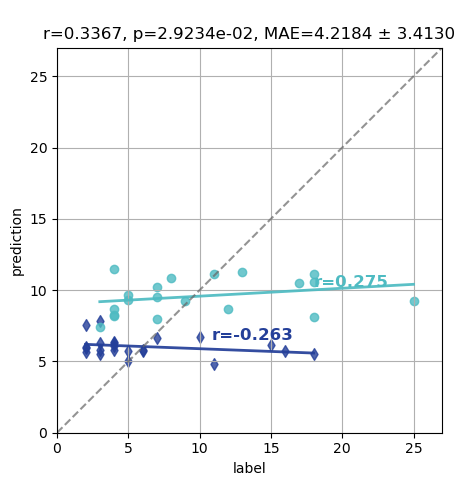

In [4]:
# "pure" SELSER implementation (no baseline clinical features)
results_dir = os.path.join(selser_base_dir, 'selser')
results_file = os.path.join(results_dir, 'prediction_results.csv')
results = aggregate_prediction_results(results_file=results_file)

# Plot results
save_path = None if not save_figs else os.path.join(selser_base_dir, 'selser_true_vs_pred.svg')
true_vs_pred_scatter_with_regressline(results, save_path=save_path)

Output file found at /home/hanna/Code/projects/2024_GNNs4DepressionTreatment/graphTRIP/outputs/selser/selser_augmented/prediction_results.csv. Loading existing results.


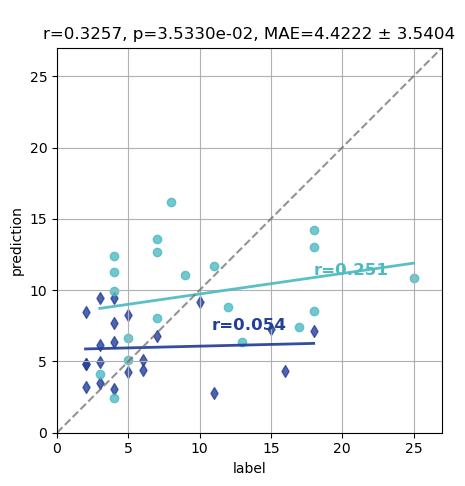

In [5]:
# Augmented SELSER implementation (with baseline clinical features)
results_dir = os.path.join(selser_base_dir, 'selser_augmented')
results_file = os.path.join(results_dir, 'prediction_results.csv')
results = aggregate_prediction_results(results_file=results_file)

# Plot results
save_path = None if not save_figs else os.path.join(selser_base_dir, 'selser_augmented_true_vs_pred.svg')
true_vs_pred_scatter_with_regressline(results, save_path=save_path)

## Medusa-graphTRIP

Output file found at /home/hanna/Code/projects/2024_GNNs4DepressionTreatment/graphTRIP/outputs/medusa_graphtrip/weights/prediction_results.csv. Loading existing results.


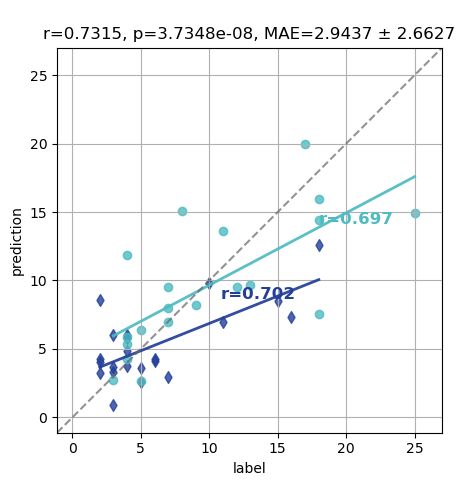

In [6]:
# Load prediction results
results_dir = os.path.join(medusa_base_dir, 'weights')
results_file = os.path.join(results_dir, 'prediction_results.csv')
pred_results = aggregate_prediction_results(results_file=results_file)

# Plot pseudo-ITE labels vs predicted ITEs
save_path = None if not save_figs else os.path.join(selser_base_dir, 'medusa_true_vs_pred.svg')
true_vs_pred_scatter_with_regressline(pred_results, save_path=save_path)